In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
# Define column names
columns = ['unit', 'cycle',
           'op_setting1', 'op_setting2', 'op_setting3']

# Add sensor columns (21 sensors total)
for i in range(1, 22):
    columns.append(f'sensor_{i}')

# Load dataset
train = pd.read_csv('train_FD001.txt', 
                    sep=' ', 
                    header=None)

# Remove extra empty columns (dataset has trailing spaces)
train = train.dropna(axis=1)

# Assign column names
train.columns = columns

# Check first few rows
train.head()

,unit,cycle,op_setting1,op_setting2,op_setting3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [47]:
print("Shape:", train.shape)
print("Number of engines:", train['unit'].nunique())
print("Max cycle:", train['cycle'].max())

Shape: (20631, 26)
Number of engines: 100
Max cycle: 362


RUL (Target variable)

In [48]:
# Get max cycle for each engine
max_cycle = train.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']

# Merge with original data
train = train.merge(max_cycle, on='unit')

# Calculate RUL
train['RUL'] = train['max_cycle'] - train['cycle']

# Drop max_cycle column
train = train.drop('max_cycle', axis=1)

train.head()

,unit,cycle,op_setting1,op_setting2,op_setting3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


Visualization

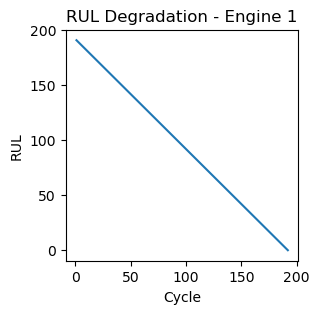

In [49]:
engine_1 = train[train['unit'] == 1]

plt.figure(figsize=(3,3))
plt.plot(engine_1['cycle'], engine_1['RUL'])
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title("RUL Degradation - Engine 1")
plt.show()

Goal of Preprocessing<br>
1. Remove useless columns
2. Handle constant sensors
3. Normalize features
4. Prepare final feature matrix

Checking sensor variance

In [50]:
# Check standard deviation of all columns
train.describe().T[['std']].sort_values(by='std')

,std
sensor_19,0.000000e+00
op_setting3,0.000000e+00
sensor_18,0.000000e+00
sensor_16,1.556432e-14
sensor_10,4.660829e-13
sensor_5,3.394700e-12
sensor_1,6.537152e-11
op_setting2,2.930621e-04
sensor_6,1.388985e-03
op_setting1,2.187313e-03


In [51]:
# Identify columns with zero variance
constant_cols = [col for col in train.columns 
                 if train[col].std() == 0]

print("Constant Columns:", constant_cols)

# Drop them
train = train.drop(columns=constant_cols)

train.shape

Constant Columns: ['op_setting3', 'sensor_18', 'sensor_19']


(20631, 24)

In [52]:
# Remove unit and RUL from features
X = train.drop(columns=['unit', 'RUL'])
y = train['RUL']

X.head()

,cycle,op_setting1,op_setting2,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,...,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_20,sensor_21
0,1,-0.0007,-0.0004,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,...,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,39.06,23.4190
1,2,0.0019,-0.0003,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,...,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,39.00,23.4236
2,3,-0.0043,0.0003,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,...,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,38.95,23.3442
3,4,0.0007,0.0000,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,...,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,38.88,23.3739
4,5,-0.0019,-0.0002,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,...,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,38.90,23.4044


Normalizing Features

In [53]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,cycle,op_setting1,op_setting2,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,...,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_20,sensor_21
0,-1.565170,-0.315980,-1.372953,0.0,-1.721725,-0.134255,-0.925936,-1.776357e-15,0.141683,1.121141,...,0.0,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-1.387779e-17,-0.781710,1.348493,1.194427
1,-1.550652,0.872722,-1.031720,0.0,-1.061780,0.211528,-0.643726,-1.776357e-15,0.141683,0.431930,...,0.0,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-1.387779e-17,-0.781710,1.016528,1.236922
2,-1.536134,-1.961874,1.015677,0.0,-0.661813,-0.413166,-0.525953,-1.776357e-15,0.141683,1.008155,...,0.0,-1.015303,1.364721,-0.919841,-0.551629,-0.649144,-1.387779e-17,-2.073094,0.739891,0.503423
3,-1.521616,0.324090,-0.008022,0.0,-0.661813,-1.261314,-0.784831,-1.776357e-15,0.141683,1.222827,...,0.0,-1.539489,1.961302,-0.224597,-0.520176,-1.971665,-1.387779e-17,-0.781710,0.352598,0.777792
4,-1.507098,-0.864611,-0.690488,0.0,-0.621816,-1.251528,-0.301518,-1.776357e-15,0.141683,0.714393,...,0.0,-0.977861,1.052871,-0.780793,-0.521748,-0.339845,-1.387779e-17,-0.136018,0.463253,1.059552


In [54]:
window_size = 5
sensor_cols = [col for col in train.columns if 'sensor_' in col]
for col in sensor_cols:
    train[f'{col}_rolling'] = train.groupby('unit')[col] \
                                    .rolling(window=window_size, min_periods=1) \
                                    .mean() \
                                    .reset_index(0, drop=True)

In [55]:
X = train.drop(columns=['unit', 'RUL'])
y = train['RUL']

Splitting by engine

In [56]:
from sklearn.model_selection import train_test_split

# Get unique engine IDs
engine_ids = train['unit'].unique()

# Split engine IDs
train_ids, val_ids = train_test_split(engine_ids, test_size=0.2, random_state=42)

# Create train and validation sets
train_data = train[train['unit'].isin(train_ids)]
val_data = train[train['unit'].isin(val_ids)]

print("Training engines:", len(train_ids))
print("Validation engines:", len(val_ids))

Training engines: 80
Validation engines: 20


In [57]:
# Training set
X_train = train_data.drop(columns=['unit', 'RUL'])
y_train = train_data['RUL']

# Validation set
X_val = val_data.drop(columns=['unit', 'RUL'])
y_val = val_data['RUL']

In [58]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [59]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_val_scaled)
y_pred

array([176.53175016, 171.56783878, 178.57630532, ...,  26.48614163,
        22.08104653,  15.32338322])

Evaluation

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 24.97581451655266
RMSE: 31.53849704642476


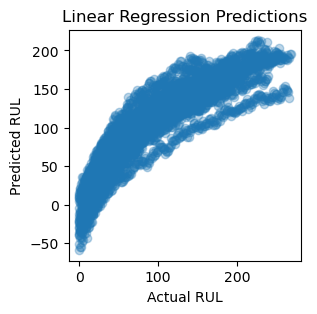

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Linear Regression Predictions")
plt.show()

Random Forest Training

In [62]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
y_pred_rf = rf_model.predict(X_val_scaled)

In [64]:
mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 24.031800982800984
Random Forest RMSE: 32.694954657019636


In [65]:
# comparison
print("Linear Regression MAE:", mae)
print("Random Forest MAE:", mae_rf)

print("Linear Regression RMSE:", rmse)
print("Random Forest RMSE:", rmse_rf)

Linear Regression MAE: 24.97581451655266
Random Forest MAE: 24.031800982800984
Linear Regression RMSE: 31.53849704642476
Random Forest RMSE: 32.694954657019636
